# Demo for the ProblemsSolvers class.

This script is intended to help with debugging problems and solvers.

It create problem-solver groups (using the directory) and runs multiple macroreplications of each problem-solver pair.

## Append SimOpt Path

Since the notebook is stored in simopt/notebooks, we need to append the parent simopt directory to the system path to import the necessary modules later on.

In [1]:
import sys
from pathlib import Path

import random 
import numpy as np 

# Take the current directory, find the parent, and add it to the system path
sys.path.append(str(Path.cwd().parent))

## Configuration Parameters

This section defines the core parameters for the demo.

To query model/problem/solver names, run `python scripts/list_directories.py`

In [ ]:
# Specify the names of the solver(s) and problem(s) to test.
solver_abbr_names = ["ASTROMORF", "ASTRODF", "NELDND", "SPSA", "ADAM", "STRONG"]
# ["DYNAMNEWS-1", "FACSIZE-1", "FIXEDSAN-1", "SAN-1"]
problem_abbr_names =  ["CONTAM-2"]
num_macroreps = 5
num_postreps = 50
num_postreps_init_opt = 50

In [3]:
# #Implement LP to get initial booking limits 
# import pulp 

# def solve_lp(f_odf, D_odf, C_l, S_l):
#     """
#     Solves the LP:
#         maximize sum_j f_j * x_j
#         subject to:
#             x_j <= D_j
#             sum_j a_ij * x_j <= C_i  for each i
#             x_j >= 0

#     Args:
#         f_odf (list[float]): coefficients f_j
#         D_odf (list[float]): upper bounds D_j
#         C_l (list[float]): capacities C_i
#         S_l (list[list[float]]): matrix a_ij (L x n)

#     Returns:
#         dict: optimal x_j values
#         float: optimal objective value
#     """
#     n = len(f_odf)
#     L = len(C_l)

#     # Create problem
#     prob = pulp.LpProblem("Maximize_fx", pulp.LpMaximize)

#     # Variables x_j >= 0
#     x = pulp.LpVariable.dicts("x", range(n), lowBound=0)

#     # Objective
#     prob += pulp.lpSum(f_odf[j] * x[j] for j in range(n))

#     # x_j <= D_j
#     for j in range(n):
#         prob += x[j] <= D_odf[j], f"x_upper_bound_{j}"

#     # Capacity constraints: sum_j a_ij * x_j <= C_i
#     for i in range(L):
#         prob += pulp.lpSum(S_l[j][i] * x[j] for j in range(n)) <= C_l[i], f"capacity_{i}"

#     # Solve
#     prob.solve(pulp.HiGHS_CMD(msg=False))

#     # Extract solution
#     x_values = {j: pulp.value(x[j]) for j in range(n)}
#     obj_value = pulp.value(prob.objective)

#     # Extract dual values (shadow prices)
#     duals = {name: c.pi for name, c in prob.constraints.items()}
#     slacks = {name: c.slack for name, c in prob.constraints.items()}

#     return x_values, obj_value

# def solve_dual(f_odf, D_odf, C_l, S_l):
#     """
#     Solves the dual LP:
#         minimize sum_i C_i * y_i + sum_j D_j * z_j
#         subject to:
#             sum_i a_ij * y_i + z_j >= f_j  for each j
#             y_i, z_j >= 0
#     Args:
#         f_odf: list of coefficients f_j
#         D_odf: upper bounds for x_j
#         C_l: capacities C_i
#         S_l: constraint matrix a_ij
#     Returns:
#         y_vals: dict of dual variables for capacity constraints
#         z_vals: dict of dual variables for x_j upper bounds
#         obj_val: optimal dual objective
#     """
#     n = len(f_odf)
#     L = len(C_l)

#     # Create problem
#     prob = pulp.LpProblem("Dual_LP", pulp.LpMinimize)

#     # Dual variables
#     y = pulp.LpVariable.dicts("y", range(L), lowBound=0)
#     z = pulp.LpVariable.dicts("z", range(n), lowBound=0)

#     # Objective
#     prob += pulp.lpSum(C_l[i] * y[i] for i in range(L)) + pulp.lpSum(D_odf[j] * z[j] for j in range(n))

#     # Constraints: sum_i a_ij * y_i + z_j >= f_j
#     for j in range(n):
#         prob += pulp.lpSum(S_l[j][i] * y[i] for i in range(L)) + z[j] >= f_odf[j], f"dual_constr_{j}"

#     # Solve
#     prob.solve(pulp.HiGHS_CMD(msg=False))

#     # Extract solution
#     y_vals = {i: pulp.value(y[i]) for i in range(L)}
#     z_vals = {j: pulp.value(z[j]) for j in range(n)}
#     obj_val = pulp.value(prob.objective)

#     return y_vals, z_vals, obj_val

# # Example usage:
# if __name__ == "__main__":
#     f_odf = [150, 100, 120, 80, 250, 170]          # coefficients
#     D_odf = [30, 60, 20, 80, 30, 40]       # demand upper bounds
#     C_l = [100, 120]                # capacities
#     S_l = [[1,0], [1, 0],[0,1],[0,1],[1,1],[1,1]]        # indices belonging to each constraint

#     x_vals, obj_val = solve_lp(f_odf, D_odf, C_l, S_l)
#     print("Optimal odf classes (x_i):")
#     for x, val in x_vals.items() : 
#         print(f'x[{x}]={val:.4f}')
#     print("\nOptimal objective value:", obj_val)

#     y_vals, z_vals, dual_obj = solve_dual(f_odf, D_odf, C_l, S_l)

#     print("\nDual solution for capacity constraints (y_i):")
#     for i, val in y_vals.items():
#         print(f"  y[{i}] = {val:.4f}")

#     print("\nDual solution for upper bounds (z_j):")
#     for j, val in z_vals.items():
#         print(f"  z[{j}] = {val:.4f}")

#     print(f"\nDual objective value: {dual_obj:.4f}")

In [4]:
def update_model_factors_dimensions(problem_name: str, new_dim: int) -> dict:
	"""
		Find the model associated with model_name and update the dimension of the factor values to the new_dim.
		Return the updated model factors.

	Args:
		model_name (str): Name of Model
		new_dim (int): New dimension for the model

	Returns:
		dict: Updated model factors
	"""
	new_factors = {}
	if problem_name == 'DYNAMNEWS-1':
		new_factors= {
			'num_prod': new_dim,
			'c_utility': [6 + j for j in range(new_dim)],
			'init_level': [3] * new_dim,
			'price': [9] * new_dim,
			'cost': [5] * new_dim,
		}
	elif problem_name == 'FACSIZE-1' or problem_name == 'FACSIZE-2':
		A = np.random.rand(new_dim, new_dim)
		new_factors= {
			'mean_vec': [500] * new_dim,
			'cov': (np.dot(A, A.T) * 100).tolist(),
			'capacity': [random.randint(100,900) for _ in range(new_dim)],
			'n_fac': new_dim,
		}
	elif problem_name == 'FIXEDSAN-1' :
		new_factors= {
		}
	elif problem_name == 'AIRLINE-1' or problem_name == 'AIRLINE-2' :
		num_classes = random.randint(2,new_dim//2)
		odf_leg_matrix = np.random.randint(0,2,(new_dim, num_classes))
		new_factors= {
			'num_classes': num_classes,
			'ODF_leg_matrix': odf_leg_matrix.tolist(),
			'prices': tuple([random.randint(50,300) for _ in range(new_dim)]),
			'capacity': tuple([random.randint(20,150) for _ in range(num_classes)]),
			'booking limits': tuple([random.randint(5,20) for _ in range(new_dim)]),
			'alpha': tuple([random.uniform(0,5) for _ in range(new_dim)]),
			'beta':  tuple([random.uniform(2,10) for _ in range(new_dim)]),
			'gamma_shape': tuple([random.uniform(2,10) for _ in range(new_dim)]),
			'gamma_scale': tuple([random.uniform(10,50) for _ in range(new_dim)]),
		}
	elif problem_name == 'NETWORK-1' :
		process_prob_elem = 1/new_dim
		mode_transit_time = [round(np.random.uniform(0.01,5),3) for _ in range(new_dim)]
		lower_limits_transit_time = [x/2 for x in mode_transit_time] 
		upper_limits_transit_time = [2*x for x in mode_transit_time]
		new_factors= {
			'process_prob': [process_prob_elem] * new_dim,
			'cost_process': [0.1 / (x + 1) for x in range(new_dim)],
			'cost_time': [round(np.random.uniform(0.01,1),3) for _ in range(new_dim)],
			'mode_transit_time': mode_transit_time,
			'lower_limits_transit_time': lower_limits_transit_time,
			'upper_limits_transit_time': upper_limits_transit_time,
			'n_networks': new_dim,
		}
	elif problem_name == 'CONTAM-2' :
		new_factors= {
			'stages': new_dim,
			'prev_decisions': (0,) * new_dim,
		}
	
	return new_factors


def update_problem_factor_dimensions(problem_name: str, new_dim: int, budget: int) -> dict:
	"""
		Update the dimension of the factor values in problem_factors to the new_dim.
		Return the updated problem factors.

	Args:
		problem_factors (dict): Problem factors to be updated
		new_dim (int): New dimension for the problem factors

	Returns:
		dict: Updated problem factors
	"""
	new_factors = {}
	if problem_name == 'DYNAMNEWS-1':
		new_factors =  {
			'initial_solution': (3,) * new_dim,
			'budget': budget,
		}
	elif problem_name == 'FACSIZE-1':
		new_factors =  {
			'initial_solution': (100,) * new_dim,
			'installation_costs': (1,) * new_dim,
			'epsilon': 0.05,
			'budget': budget,
		}
	elif problem_name == 'FACSIZE-2':
		new_factors =  {
			'initial_solution': (300,) * new_dim,
			'installation_costs': (1,) * new_dim,
			'installation_budget': 500.0,
			'budget': budget,
		}
	elif problem_name == 'FIXEDSAN-1' : 
		new_factors =  {
			'budget': budget,
		}
	elif problem_name == 'AIRLINE-1' or problem_name == 'AIRLINE-2' :
		new_factors =  {
			'initial_solution': (3,) * new_dim,
			'budget': budget,
		}
	elif problem_name == 'NETWORK-1' :
		init_soln_elem = 1/new_dim
		new_factors =  {
			'initial_solution': (init_soln_elem,) * new_dim,
			'budget': budget,
		}
	elif problem_name == 'CONTAM-2' :
		new_factors = {
			'initial_solution': (1,) * new_dim,
			'prev_cost': [1] * new_dim,
			'error_prob': [0.2] * new_dim,
			'upper_thres': [0.1] * new_dim,
			'budget': budget,
		}
	return new_factors

In [5]:
from simopt.experiment_base import ProblemSolver
def populate_experiments(problems, solvers):
    # Create a list of list of ProblemSolvers to be passed through the ProblemsSolvers constructor 
    problem_solvers = []
    for solver in solvers : 
        solvers_ps = []
        if solver.name == 'ASTROMORF' :
            solver_rename = f'ASTROMORF_dim{solver.factors["initial subspace dimension"]}'
        else : 
            solver_rename = solver.name
        for problem in problems :
            solvers_ps.append(ProblemSolver(problem=problem, solver=solver, solver_rename=solver_rename))
        problem_solvers.append(solvers_ps)

    return problem_solvers

In [6]:
from simopt import solvers
from simopt.experiment_base import instantiate_problem, instantiate_solver
#Create Solver and Problem instances
budget = 10000 
subspace_dim = 5
new_dim = 30 
poly_basis = 'ChebyshevTensorBasis'

solver_fixed_factors = [
    {'crn_across_solns': False, 'initial subspace dimension': 1},
    {'crn_across_solns': False, 'initial subspace dimension': 2},
    {'crn_across_solns': False, 'initial subspace dimension': 3},
    {'crn_across_solns': False, 'initial subspace dimension': 4},
    {'crn_across_solns': False, 'initial subspace dimension': 5},
    {'crn_across_solns': False, 'initial subspace dimension': 6},
    {'crn_across_solns': False, 'initial subspace dimension': 7},
    {'crn_across_solns': False, 'initial subspace dimension': 8},
    {'crn_across_solns': False, 'initial subspace dimension': 9},
    {'crn_across_solns': False, 'initial subspace dimension': 10},
    ]

solvers_ASTROMoRF = [instantiate_solver(solver_name='ASTROMORF', fixed_factors=fixed) for fixed in solver_fixed_factors]
# solvers_ASTROMoRF = [instantiate_solver(solver_name='ASTROMORF', fixed_factors={'crn_across_solns': False})]
# solvers_ASTRODF = [instantiate_solver(solver_name='ASTRODF', fixed_factors={'crn_across_solns': False})]

solvers = solvers_ASTROMoRF 
problems = [instantiate_problem(problem_name=name) for name in problem_abbr_names]

problem_solvers = populate_experiments(problems, solvers)

# problem_solvers = [[ProblemSolver(problem=problem, solver=solver) for problem in problems] for solver in solvers]




# problems = [instantiate_problem(problem_name=name, problem_fixed_factors=update_problem_factor_dimensions(name,new_dim,budget), model_fixed_factors=update_model_factors_dimensions(name,new_dim)) for name in problem_abbr_names]
  
# problems = []
# while problems == [] :
#     try :
        
#         problems = [instantiate_problem(problem_name=name, problem_fixed_factors=update_problem_factor_dimensions(name,new_dim,budget), model_fixed_factors=update_model_factors_dimensions(name,new_dim)) for i,name in enumerate(problem_abbr_names)]
#     except ValueError :
#         pass


In [7]:
# Initialize an instance \of the experiment class.
from simopt.experiment_base import ProblemsSolvers

mymetaexperiment = ProblemsSolvers(experiments=problem_solvers, file_name_path='subspace_dimension_experiment_results.pkl')

# Write to log file. 
mymetaexperiment.log_group_experiment_results()

In [8]:
# Run a fixed number of macroreplications of each solver on each problem.
mymetaexperiment.run(n_macroreps=num_macroreps)


✓ ASTROMoRF Solver completed. Diagnostics written to: /Users/benjaminrees/Desktop/simopt/Diagnostics/astromorf_diagnostics_CONTAM-1_2025-11-16_19-19-37.txt

✓ ASTROMoRF Solver completed. Diagnostics written to: /Users/benjaminrees/Desktop/simopt/Diagnostics/astromorf_diagnostics_CONTAM-1_2025-11-16_19-19-47.txt

✓ ASTROMoRF Solver completed. Diagnostics written to: /Users/benjaminrees/Desktop/simopt/Diagnostics/astromorf_diagnostics_CONTAM-1_2025-11-16_19-19-56.txt

✓ ASTROMoRF Solver completed. Diagnostics written to: /Users/benjaminrees/Desktop/simopt/Diagnostics/astromorf_diagnostics_CONTAM-1_2025-11-16_19-20-05.txt

✓ ASTROMoRF Solver completed. Diagnostics written to: /Users/benjaminrees/Desktop/simopt/Diagnostics/astromorf_diagnostics_CONTAM-1_2025-11-16_19-20-14.txt

✓ ASTROMoRF Solver completed. Diagnostics written to: /Users/benjaminrees/Desktop/simopt/Diagnostics/astromorf_diagnostics_CONTAM-1_2025-11-16_19-20-24.txt

✓ ASTROMoRF Solver completed. Diagnostics written to: /Us

In [9]:
def run_difference_variance(runs):
    # Convert each run into a 2D NumPy array
    runs = [np.array(run) for run in runs]  # shape: (iters, dims)

    # 1. Compute centroid (mean recommended solution) for each run
    centroids = np.array([run.mean(axis=0) for run in runs])
    # shape: (num_runs, dims)

    # 2. Compute variance across runs
    variance_across_runs = np.var(centroids, axis=0, ddof=1)

    # 3. Optional: combine into a single scalar
    avg_variance = variance_across_runs.mean()

    return avg_variance, variance_across_runs, centroids

In [10]:
data_list = [a for x in mymetaexperiment.experiments for a in x]
vars_for_subs = {}

#Summarize results
for exp in data_list : 
    print(f'The number of iterations for solver {exp.solver.name} on problem {exp.problem.name} is: {len(exp.all_recommended_xs[0])}')
    terminal_sols =  [exp.all_recommended_xs[i][-1] for i in range(len(exp.all_recommended_xs))]
    
    terminal_sol = [exp.solver.create_new_solution(tuple(terminal_sols[i]), exp.problem) for i in range(len(terminal_sols))]

    [exp.problem.simulate(terminal_sol[i], 750) for i in range(len(terminal_sol))]

    #terminal_sol_and_vals is a list of tuples of the objective function value and corresponding solution
    terminal_sol_and_vals = [(terminal_sol[i].objectives_mean.item(), terminal_sol[i]) for i in range(len(terminal_sol))]

    if exp.problem.minmax[0] == 1 :
        #within terminal_sol_and_vals find the maximum objective value and corresponding solution
        optimal_sol_val =  max(terminal_sol_and_vals, key=lambda x: x[0])
    else : 
        optimal_sol_val =  min(terminal_sol_and_vals, key=lambda x: x[0])


    #Group together all solutions of the same iteration at each macroreplication
    avg_rns, var_across_runs, centroids = run_difference_variance(exp.all_recommended_xs)
    print(f"Average variance (difference across runs):\n {avg_rns}")
    print(f"Variance per dimension:\n {var_across_runs}")
    print(f"Centroids (mean solution per run):\n {centroids}")
    if "ASTROMORF" in exp.solver.name :
        vars_for_subs[exp.solver.factors['initial subspace dimension']] = float(avg_rns)
    

    print(f'Variance of recommended solutions at each iteration for solver {exp.solver.name} on problem {exp.problem.name} is: {float(avg_rns)}')

    print(f'The best solution found by solver {exp.solver.name} on problem {exp.problem.name} is: \n{optimal_sol_val[1].x} \n {optimal_sol_val[0]}')
    print(f'The average objective value over all macroreplications is: {np.mean([terminal_sol_and_vals[i][0] for i in range(len(terminal_sol_and_vals))])}')
    print(' ')



The number of iterations for solver ASTROMORF_dim1 on problem CONTAM-1 is: 170
Average variance (difference across runs):
 3.851859888774472e-34
Variance per dimension:
 [0.00000000e+00 3.85185989e-33 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00]
Centroids (mean solution per run):
 [[0.54901163 0.44824415 0.51591855 0.42665796 0.42665796 0.42665796
  0.42665796 0.42665796 0.42665796 0.42665796]
 [0.54901163 0.44824415 0.51591855 0.42665796 0.42665796 0.42665796
  0.42665796 0.42665796 0.42665796 0.42665796]
 [0.54901163 0.44824415 0.51591855 0.42665796 0.42665796 0.42665796
  0.42665796 0.42665796 0.42665796 0.42665796]
 [0.54901163 0.44824415 0.51591855 0.42665796 0.42665796 0.42665796
  0.42665796 0.42665796 0.42665796 0.42665796]
 [0.54901163 0.44824415 0.51591855 0.42665796 0.42665796 0.42665796
  0.42665796 0.42665796 0.42665796 0.42665796]]
Variance of recommended solutions at each iteration for solver A

{1: 3.851859888774472e-34, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0, 6: 1.5407439555097887e-33, 7: 1.1555579666323415e-33, 8: 0.0, 9: 3.851859888774472e-34, 10: 0.0}


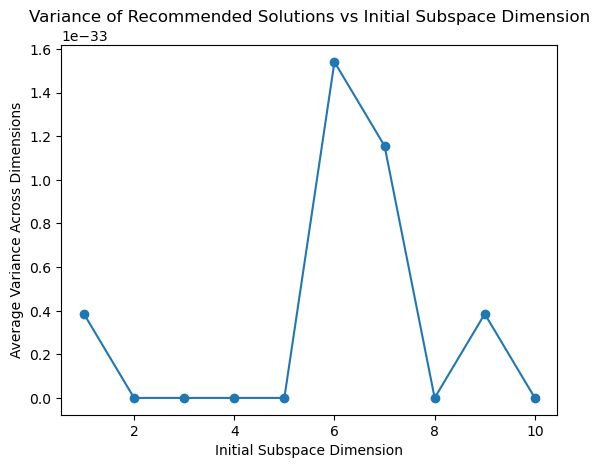

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
print(vars_for_subs)
plt.plot(list(vars_for_subs.keys()), [np.mean(vars_for_subs[key]) for key in vars_for_subs.keys()], marker='o')
plt.xlabel('Initial Subspace Dimension')
plt.ylabel('Average Variance Across Dimensions')
plt.title('Variance of Recommended Solutions vs Initial Subspace Dimension')
# plt.yscale('log')
plt.savefig('variance_vs_subspace_dimension.png')
plt.show()

In [12]:
print("Post-processing results.")
# Run a fixed number of postreplications at all recommended solutions.
mymetaexperiment.post_replicate(n_postreps=num_postreps)

Post-processing results.


In [13]:
print("Post-normalizing results.")

# Find an optimal solution x* for normalization.
mymetaexperiment.post_normalize(n_postreps_init_opt=num_postreps_init_opt)

Post-normalizing results.


Plotting results...
Plot saved to [PosixPath('/Users/benjaminrees/Desktop/simopt/experiments/2025-11-16_19-19-37/plots/SOLVER_SET_PROBLEM_SET_profile_cdf_0.1_solve_times.png')]
Plotting complete!


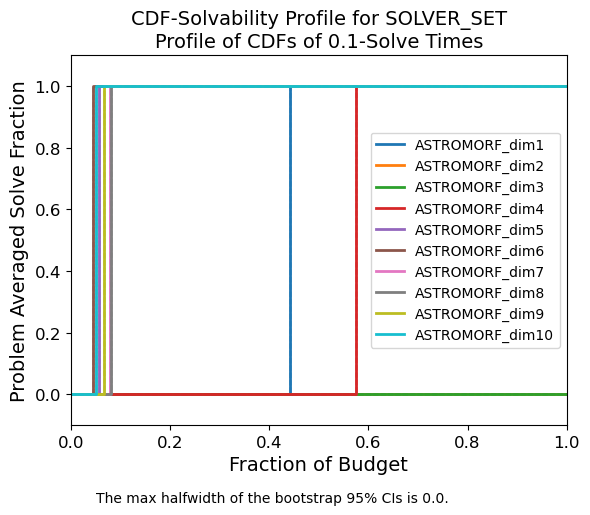

In [14]:
# Produce basic plots.

from simopt.experiment_base import PlotType, plot_solvability_profiles

print("Plotting results...")

def _print_path(plot_path: list[Path]) -> Path:
    print(f"Plot saved to {plot_path!s}")
    return plot_path[0]



group_plot = _print_path(
    plot_solvability_profiles(
        experiments=mymetaexperiment.experiments, plot_type=PlotType.CDF_SOLVABILITY, solve_tol=0.1
    )
)


print("Plotting complete!")

Plot saved to [PosixPath('/Users/benjaminrees/Desktop/simopt/experiments/2025-11-16_19-19-37/plots/SOLVER_SET_CONTAM-1_all_prog_curves_unnorm.png')]
Plot saved to [PosixPath('/Users/benjaminrees/Desktop/simopt/experiments/2025-11-16_19-19-37/plots/SOLVER_SET_CONTAM-1_mean_prog_curve_unnorm.png')]
Plot saved to [PosixPath('/Users/benjaminrees/Desktop/simopt/experiments/2025-11-16_19-19-37/plots/SOLVER_SET_CONTAM-1_all_prog_curves_unnorm (1).png')]
Plot saved to [PosixPath('/Users/benjaminrees/Desktop/simopt/experiments/2025-11-16_19-19-37/plots/SOLVER_SET_CONTAM-1_mean_prog_curve_unnorm (1).png')]
Plot saved to [PosixPath('/Users/benjaminrees/Desktop/simopt/experiments/2025-11-16_19-19-37/plots/SOLVER_SET_CONTAM-1_all_prog_curves_unnorm (1) (2).png')]
Plot saved to [PosixPath('/Users/benjaminrees/Desktop/simopt/experiments/2025-11-16_19-19-37/plots/SOLVER_SET_CONTAM-1_mean_prog_curve_unnorm (1) (2).png')]
Plot saved to [PosixPath('/Users/benjaminrees/Desktop/simopt/experiments/2025-11-1

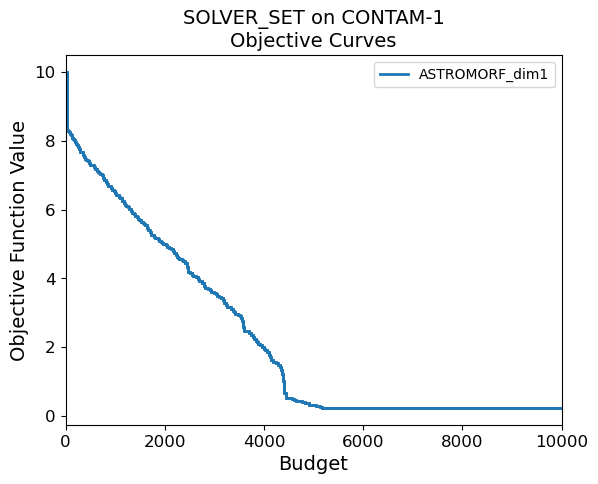

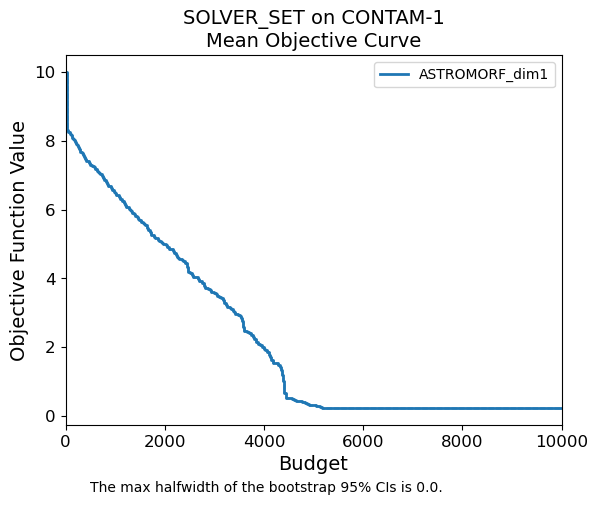

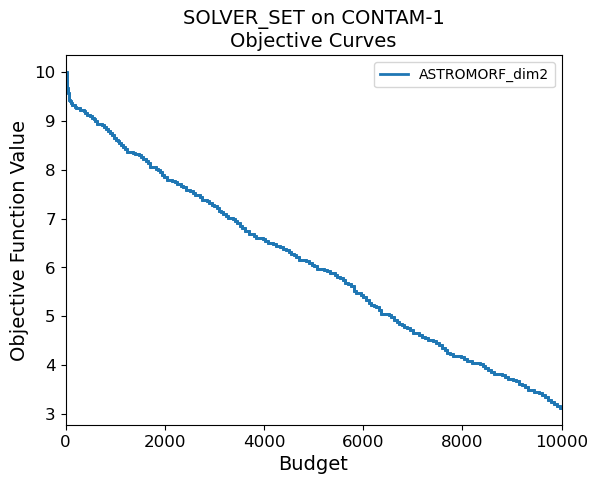

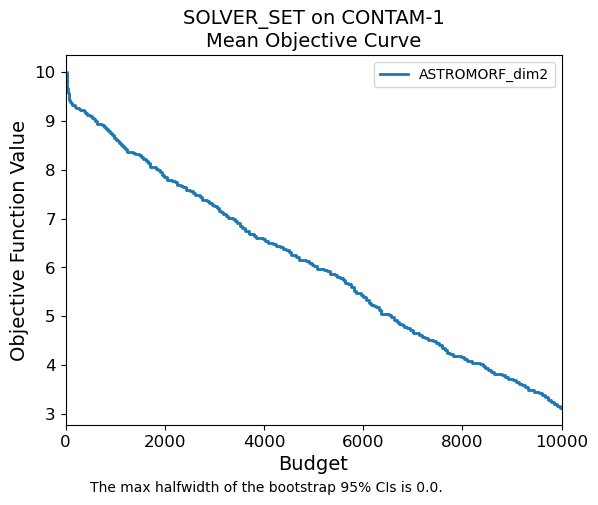

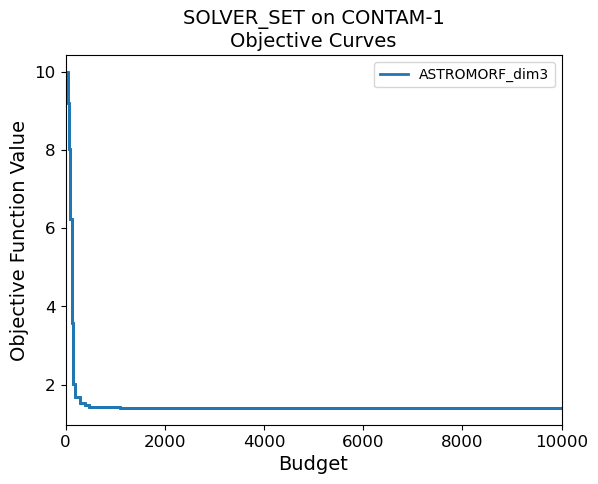

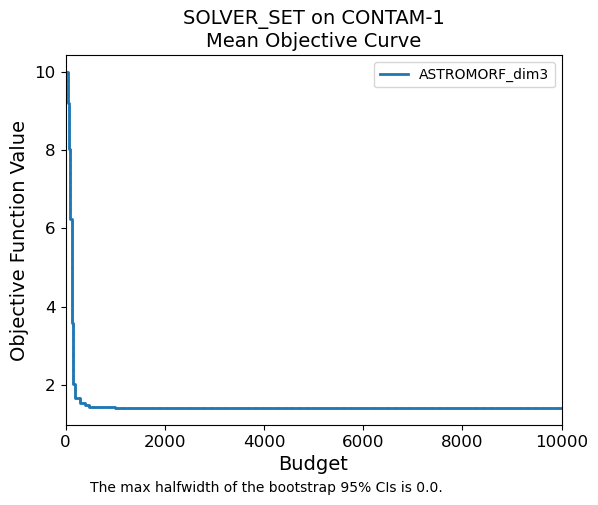

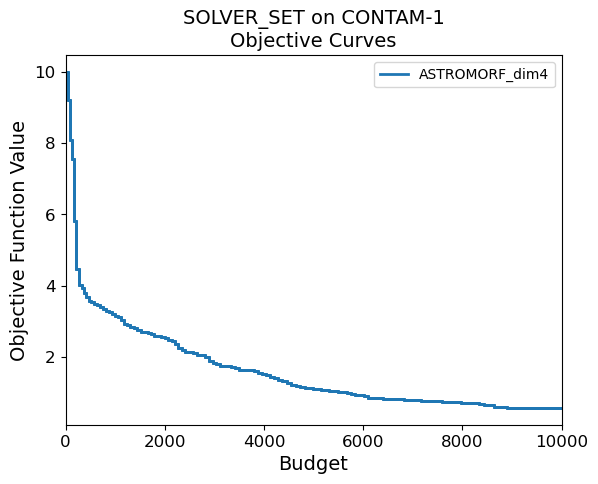

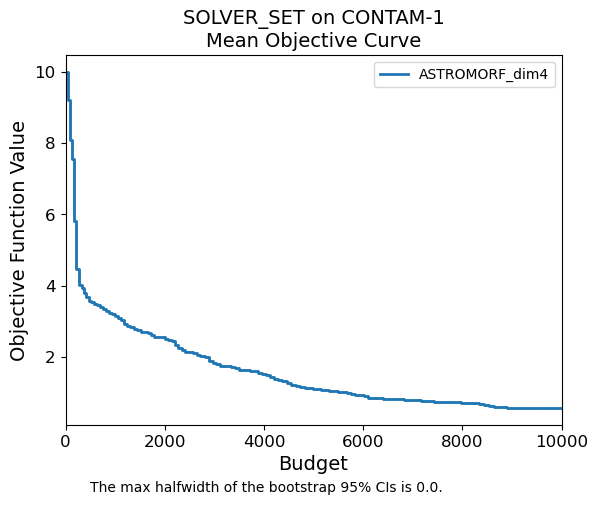

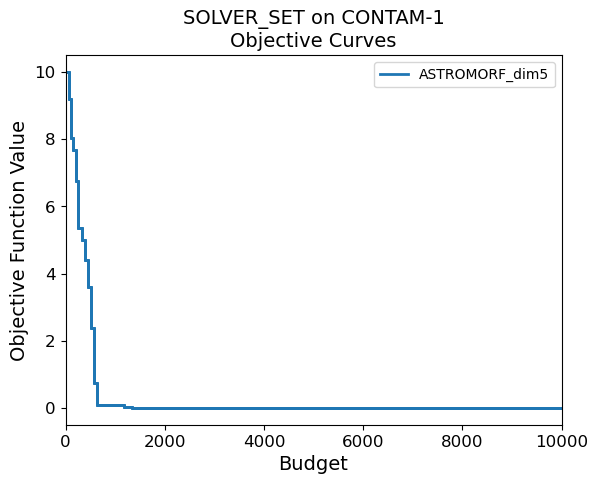

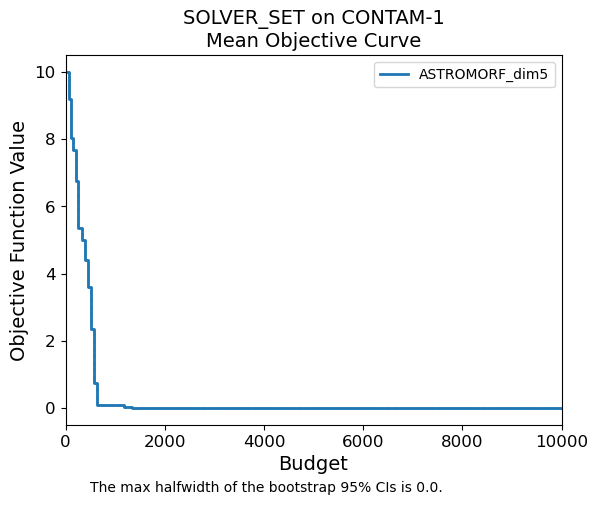

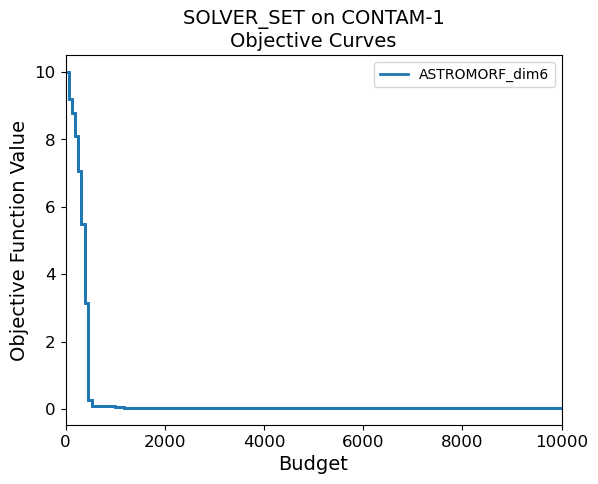

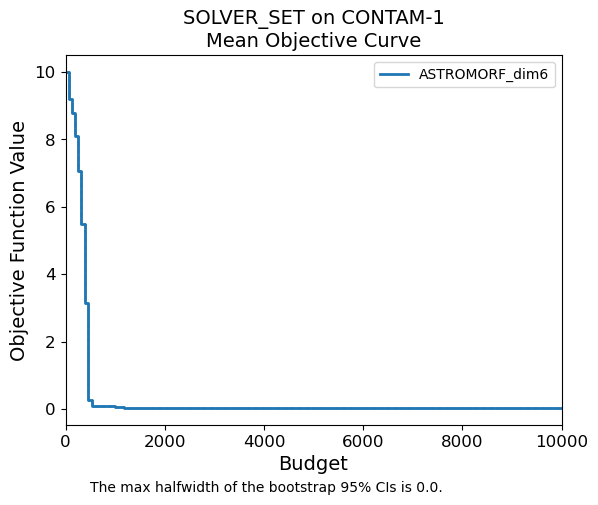

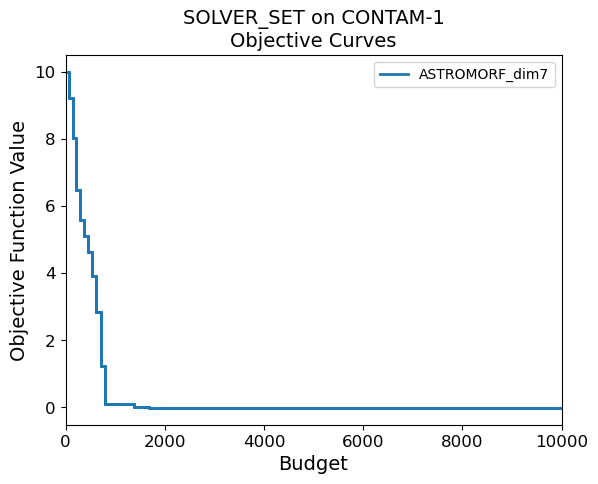

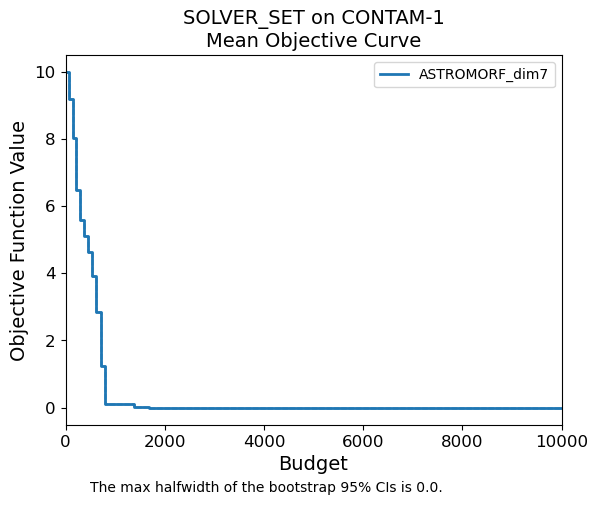

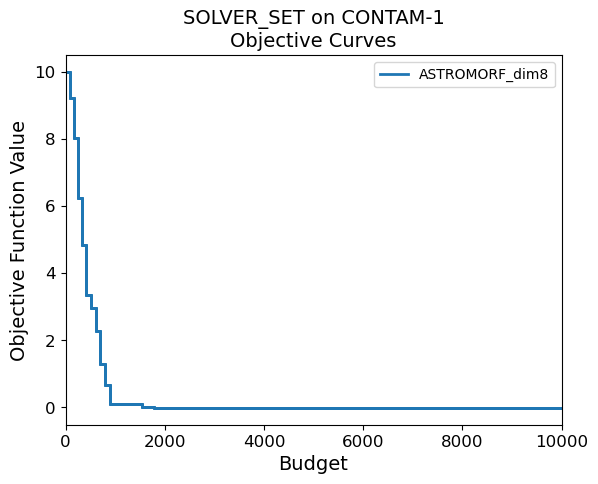

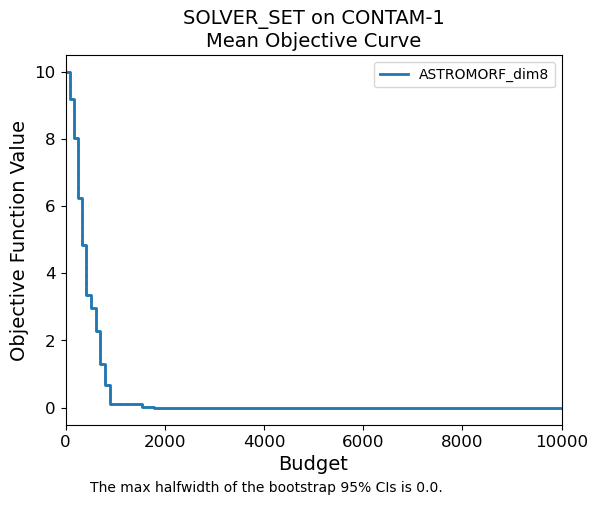

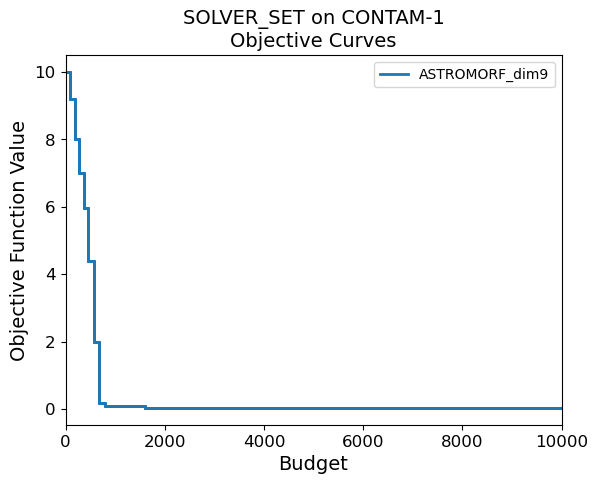

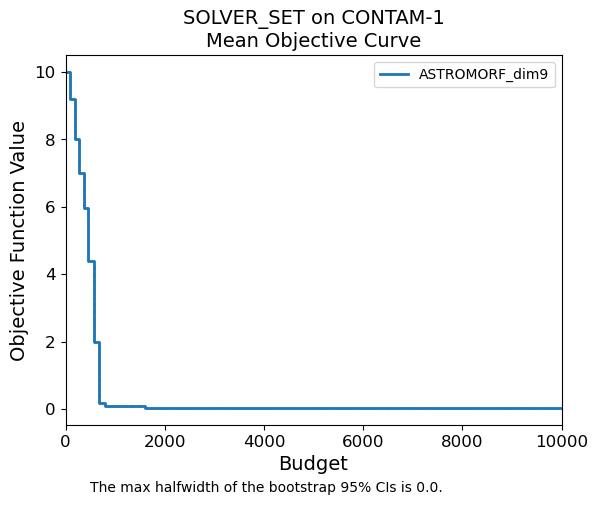

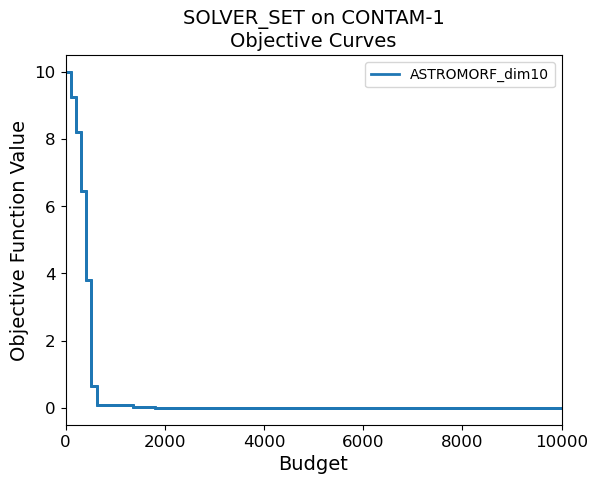

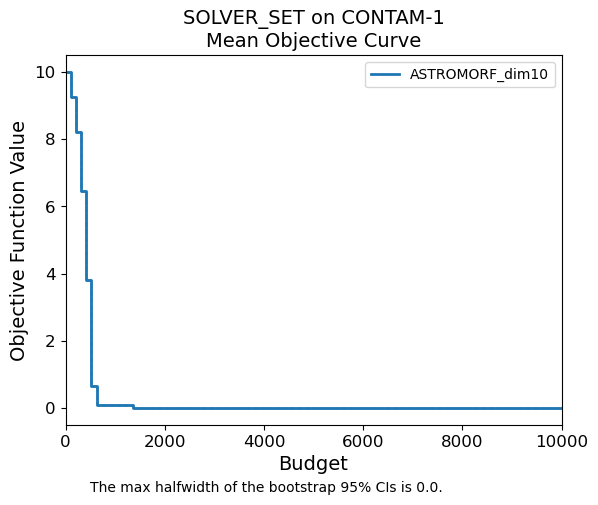

In [15]:
#plot individual plots 
from simopt.experiment_base import plot_progress_curves

ind_plots = []
for myexperiment in data_list :
    _print_path(
    plot_progress_curves(
        experiments=[myexperiment], plot_type=PlotType.ALL, normalize=False
        )
    )
    ind_plot = _print_path(
        plot_progress_curves(
            experiments=[myexperiment], plot_type=PlotType.MEAN, normalize=False
        )
    )
    ind_plots.append(ind_plot)


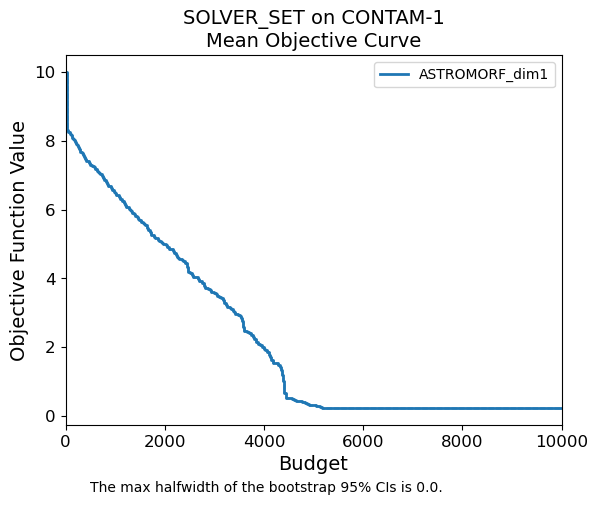

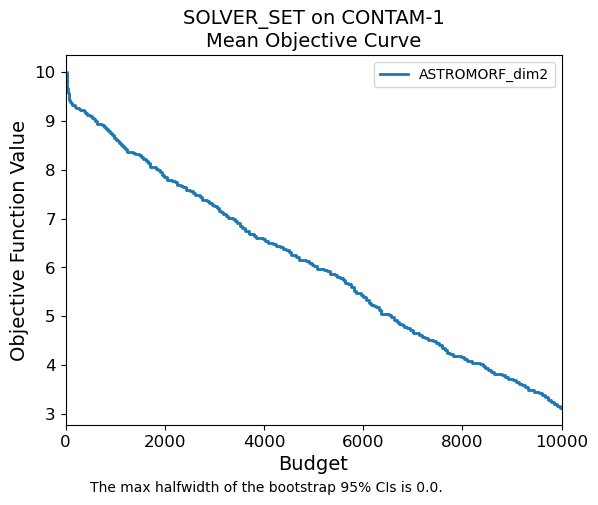

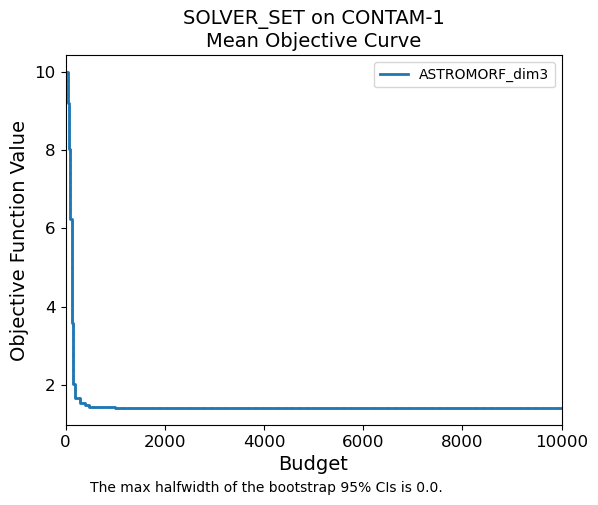

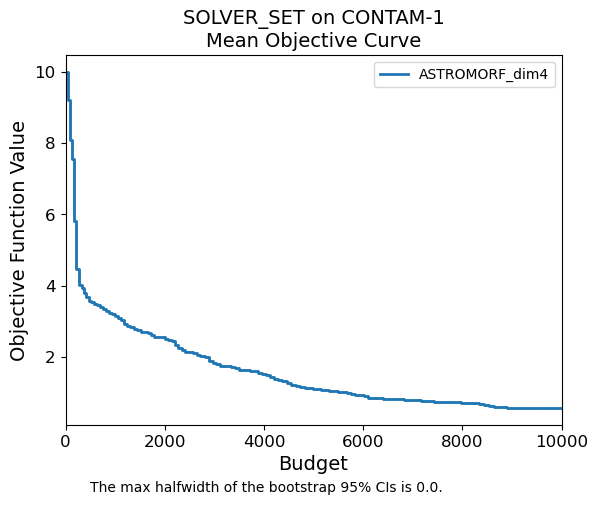

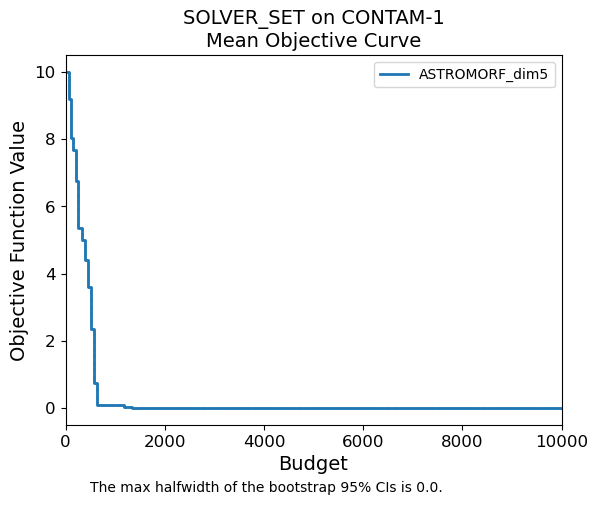

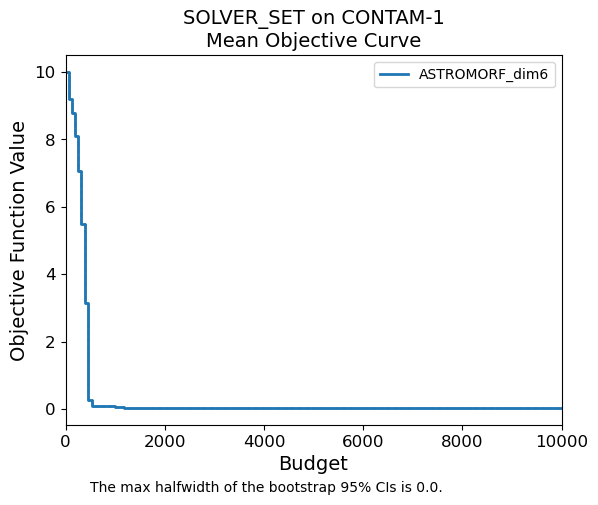

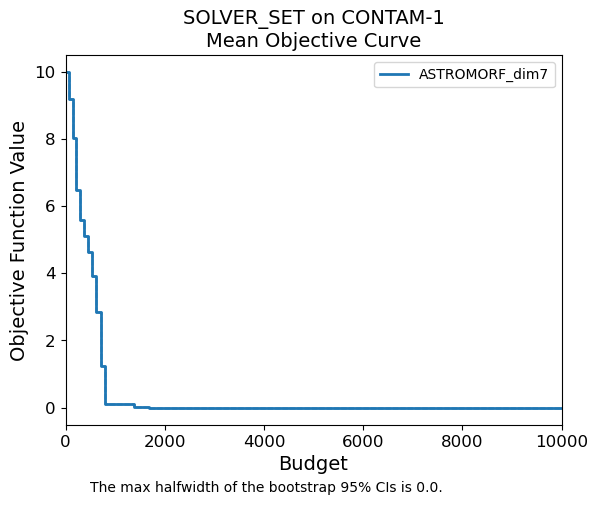

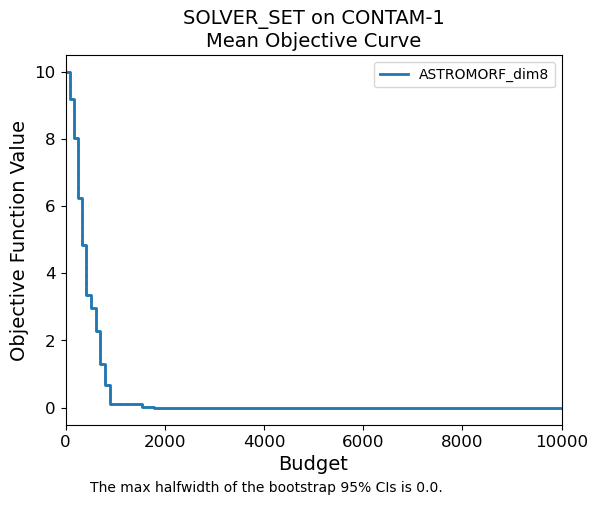

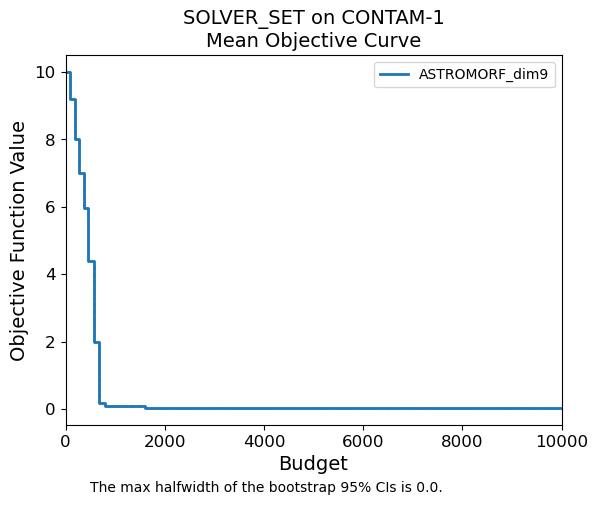

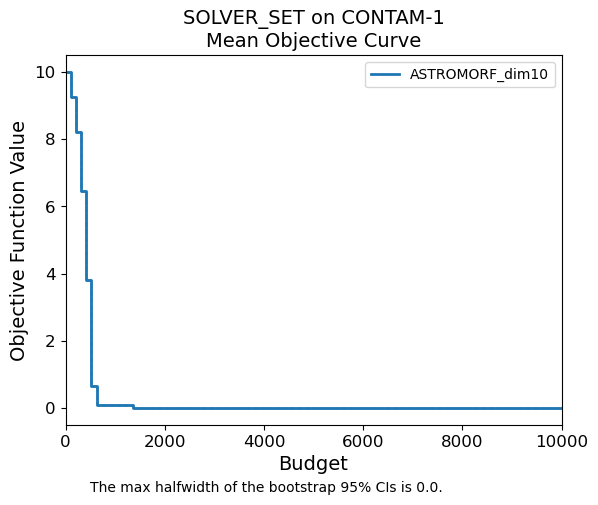

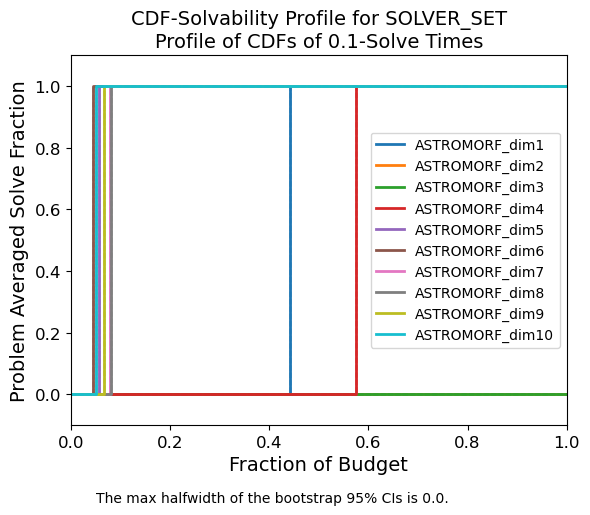

In [16]:
#show plots
from IPython.display import Image, display
from pathlib import Path

plots = ind_plots 

no_of_prolems = len(problem_abbr_names)


for i in range(len(plots)) :
    display(Image(filename=str(plots[i])))
# Example POSIX path
# for i in range(no_of_prolems) :
#     # Display the image
#     other_solver_same_problem_index = i + no_of_prolems if i < no_of_prolems else i - no_of_prolems
#     display(Image(filename=str(ind_plots[i])))
#     #display the same p
#     display(Image(filename=str(ind_plots[other_solver_same_problem_index])))

#Display solvability profile
display(Image(filename=str(group_plot)))

